# 01 — Exploring the data

This notebook is where we **look at the data before trusting it**. The final charts are made by `run_all.py`; here we check what the data contains, what is missing and what looks strange.

Run `python run_all.py` once first so the cleaned file exists.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Let the notebook import our own files from src/
sys.path.insert(0, str(Path.cwd().parent / "src"))
import config

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 20)

## 1. How big is the raw file?

In [2]:
raw = pd.read_csv(config.RAW_DATA_FILE)
print("rows, columns:", raw.shape)
print("years covered:", raw["year"].min(), "to", raw["year"].max())
print("number of countries/regions:", raw["country"].nunique())

rows, columns: (23377, 130)
years covered: 1900 to 2025
number of countries/regions: 314


The raw file has one row per **country per year** and about 130 columns. We only need a few of them.

In [3]:
gcc = raw[raw["country"].isin(config.GCC_COUNTRIES)]
gcc[config.COLUMNS].tail(8)

,country,year,population,electricity_generation,renewables_share_elec,solar_share_elec,wind_share_elec,nuclear_share_elec,low_carbon_share_elec,gas_share_elec,oil_share_elec,per_capita_electricity,carbon_intensity_elec
21739,United Arab Emirates,2017,9234330.0,134.57,0.557,0.557,0.000,0.000,0.557,99.443,0.0,14572.796,673.26
21740,United Arab Emirates,2018,9346870.0,136.01,0.882,0.882,0.000,0.000,0.882,99.118,0.0,14551.395,671.20
21741,United Arab Emirates,2019,9377855.0,138.45,2.644,2.644,0.000,0.000,2.644,97.356,0.0,14763.504,660.09
21742,United Arab Emirates,2020,9448529.0,137.31,3.772,3.772,0.000,1.187,4.960,94.509,0.0,14532.421,645.69
21743,United Arab Emirates,2021,9789055.0,149.05,4.193,4.193,0.000,7.078,11.271,86.709,0.0,15226.189,605.30
21744,United Arab Emirates,2022,10242085.0,155.42,4.986,4.980,0.000,12.933,17.919,82.081,0.0,15174.645,558.49
21745,United Arab Emirates,2023,10642089.0,167.53,8.757,8.595,0.036,20.558,29.314,70.686,0.0,15742.210,483.79
21746,United Arab Emirates,2024,11027135.0,177.26,8.812,8.581,0.113,22.921,31.733,68.267,0.0,16074.892,467.51


## 2. Where is data missing?

For each column: what percentage of GCC rows since 2010 are empty?

In [4]:
recent = gcc[gcc["year"] >= config.START_YEAR][config.COLUMNS]
(recent.isna().mean() * 100).round(1).sort_values(ascending=False)

country                   0.0
year                      0.0
population                0.0
electricity_generation    0.0
renewables_share_elec     0.0
solar_share_elec          0.0
wind_share_elec           0.0
nuclear_share_elec        0.0
low_carbon_share_elec     0.0
gas_share_elec            0.0
oil_share_elec            0.0
per_capita_electricity    0.0
carbon_intensity_elec     0.0
dtype: float64

For the GCC countries since 2010, **no values are missing** in the columns we use. Missing values are not the problem here — but the next section shows a different data-quality problem.

## 3. Something strange: a repeated year

Kuwait's 2025 row has exactly the same values as 2024. Real measurements almost never repeat exactly, so this is probably a value carried forward until new data arrives. `clean_data.py` flags such rows and the analysis leaves them out.

In [5]:
cols = ["country", "year", "electricity_generation", "renewables_share_elec", "low_carbon_share_elec"]
raw[(raw["country"] == "Kuwait") & (raw["year"] >= 2023)][cols]

,country,year,electricity_generation,renewables_share_elec,low_carbon_share_elec
10951,Kuwait,2023,89.76,2.128,2.128
10952,Kuwait,2024,92.49,2.238,2.238
10953,Kuwait,2025,92.49,2.238,2.238


## 4. The cleaned table

In [6]:
clean = pd.read_csv(config.CLEAN_DATA_FILE)
print(clean.shape)
clean[clean["repeated_from_previous_year"]]

(109, 14)


,country,year,population,electricity_generation,renewables_share_elec,solar_share_elec,wind_share_elec,nuclear_share_elec,low_carbon_share_elec,gas_share_elec,oil_share_elec,per_capita_electricity,carbon_intensity_elec,repeated_from_previous_year
30,Kuwait,2025,5026079.0,92.49,2.238,0.227,2.011,0.0,2.238,62.007,35.755,18402.018,635.31,True


## 5. Quick summary statistics (latest reliable year)

In [7]:
import analysis

df = analysis.load_clean()
analysis.summary_table(df)

,country,latest_year,low_carbon_share_%,renewables_share_%,nuclear_share_%,kwh_per_person,co2_g_per_kwh_2010,co2_g_per_kwh_latest,generation_growth_%
1,UAE,2024,31.7,8.8,22.9,16075,677,468,89
4,Oman,2025,4.5,4.5,0.0,9617,567,544,167
2,Qatar,2025,4.1,4.1,0.0,18030,604,582,100
0,Saudi Arabia,2024,2.2,2.2,0.0,13386,691,692,83
3,Kuwait,2024,2.2,2.2,0.0,18744,653,635,62
5,Bahrain,2024,0.3,0.3,0.0,23615,905,902,59


## 6. A quick first look at the trend

A rough plot, just for exploring (the polished charts are in `reports/figures/`).

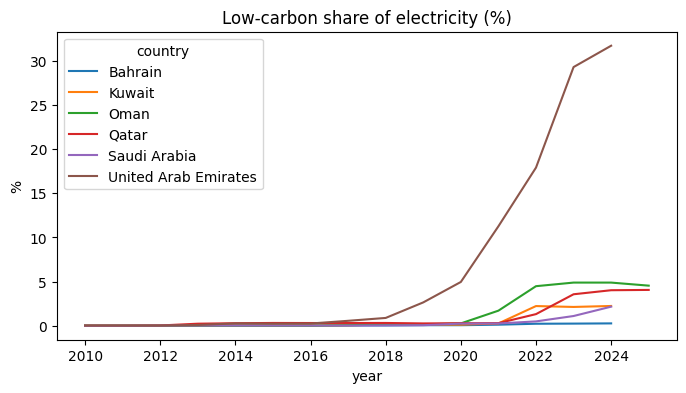

In [8]:
import matplotlib.pyplot as plt

pivot = df[df["country"].isin(config.GCC_COUNTRIES)].pivot(index="year", columns="country", values="low_carbon_share_elec")
pivot.plot(figsize=(8, 4), title="Low-carbon share of electricity (%)")
plt.ylabel("%")
plt.show()

## 7. What I noticed

- Five of the six countries still make more than 95% of their electricity from gas and oil.
- The UAE is the exception, mostly because of nuclear power from 2020 onwards.
- Solar growth started around 2021–2023 in most countries, so the trend is very recent.
- The newest year is sometimes missing or repeated, so always check the latest data point.

**Question to explore next:** does electricity demand grow faster than solar is being added?